In [1]:
!pip freeze > requirements.txt

This command exports all installed Python packages and their versions from the current environment into a requirements.txt file.

In [2]:
import pandas
import matplotlib.pyplot as plt
import seaborn as sns

The following libraries were imported to support data analysis, visualisation, and machine learning tasks within the project

In [3]:
# Model performance results
comparison = pandas.DataFrame({
'Metric': [
'Accuracy',
'Precision',
'Recall',
'F1 Score',
'ROC-AUC'
],
'Logistic Regression': [
0.647,
0.588,
0.994,
0.739,
0.719 
],
'Random Forest': [
0.976,
0.974,
0.978,
0.976,
0.997
]
})

This DataFrame stores the evaluation results from both machine learning models in a structured format. It allows the performance of each model to be compared using standard classification metrics.
 
### Metrics Included
 
- **Accuracy**: Measures the percentage of correct predictions made by the model.
- **Precision**: Measures how many predicted churn cases were actually churned customers.
- **Recall**: Measures how many actual churned customers were correctly identified.
- **F1 Score**: Provides a balance between Precision and Recall.
- **ROC-AUC**: Measures the model's ability to distinguish between churned and retained customers.

In [4]:
# Calculate improvement
comparison['Difference'] = (
comparison['Random Forest']
- comparison['Logistic Regression']
)
 
print("\nModel Comparison")
print(comparison)


Model Comparison
      Metric  Logistic Regression  Random Forest  Difference
0   Accuracy                0.647          0.976       0.329
1  Precision                0.588          0.974       0.386
2     Recall                0.994          0.978      -0.016
3   F1 Score                0.739          0.976       0.237
4    ROC-AUC                0.719          0.997       0.278


The following code calculates the difference between the performance of the Random Forest model and the Logistic Regression model for each evaluation metric.

In [5]:
# Prepare data for plotting
plot_data = comparison.melt(
id_vars='Metric',
value_vars=[
'Logistic Regression',
'Random Forest'
],
var_name='Model',
value_name='Score'
)

The following code reshapes the model comparison DataFrame into a format suitable for visualisation using Seaborn. This visualisation makes it easier to identify which model performed best and supports the conclusion that the Random Forest model achieved superior overall performance.

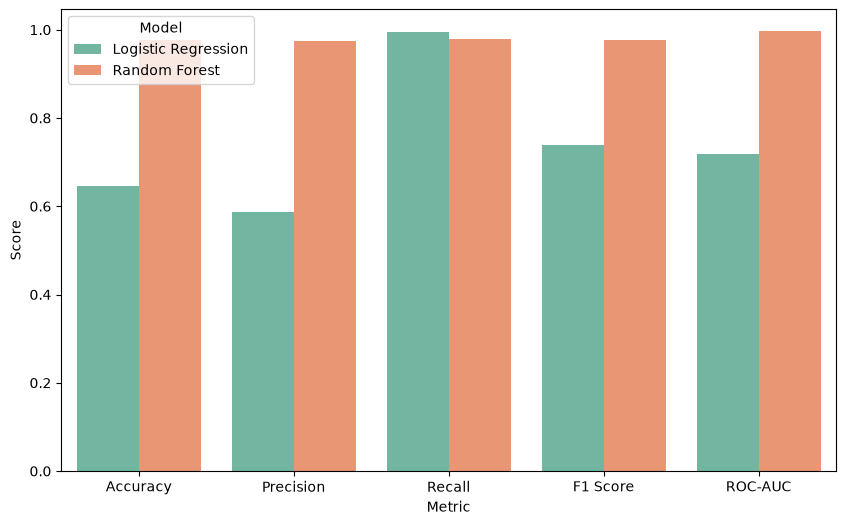

In [6]:
# Plot comparison
plt.figure(figsize=(10, 6))
 
ax = sns.barplot(
data=plot_data,
x='Metric',
y='Score',
hue='Model',
palette='Set2'
)

In [7]:
# Add values above bars
# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3
    )

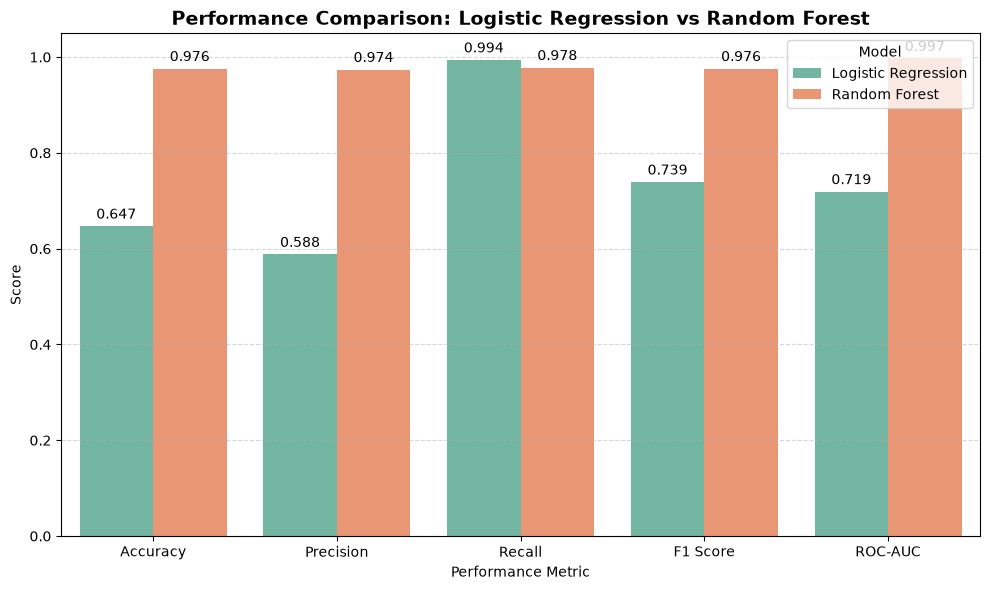

In [ ]:
comparison = pandas.DataFrame({
'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
'Logistic Regression': [0.647, 0.588, 0.994, 0.739, 0.719],
'Random Forest': [0.976, 0.974, 0.978, 0.976, 0.997]
})
 
# Convert to long format
plot_data = comparison.melt(
id_vars='Metric',
var_name='Model',
value_name='Score'
)
 
plt.figure(figsize=(10, 6))
 
ax = sns.barplot(
data=plot_data,
x='Metric',
y='Score',
hue='Model',
palette='Set2'
)
 
# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3
    )
plt.title(
'Performance Comparison: Logistic Regression vs Random Forest',
fontsize=14,
fontweight='bold'
)
 
plt.ylabel('Score')
plt.xlabel('Performance Metric')
plt.ylim(0, 1.05)
 
plt.legend(title='Model')
 
plt.grid(
axis='y',
linestyle='--',
alpha=0.5
)
 
plt.tight_layout()
 
plt.savefig(
'model_comparison.png',
dpi=300,
bbox_inches='tight'
)
 
plt.show()

The bar chart compares the performance of the Logistic Regression and Random Forest models across Accuracy, Precision, Recall, F1-Score, and ROC-AUC. The results show that Random Forest outperformed Logistic Regression in almost all metrics, making it the more accurate and reliable model for predicting customer churn.